# Band-integration validation: synphot + specutils on a DIRSIG-shaped cube

**ADR-0001 Action Item 3 / ADR-0002 Notebook 3.** This notebook establishes and validates the
**band-integration physics** — SED × bandpass × QE → count rate / magnitude — that later becomes a
differentiable, GPU-native component (ADR Action Item 4). Here we use **synphot** as the reference
implementation and **specutils** as the cube container, to pin down the physics and answer one open
question the ADR flagged.

**Two concrete goals:**

1. **Resolve the ADR's open question:** *"Whether `synphot.Observation` batch-integrates across a
   multidimensional specutils `Spectrum1D` in one call, or only accepts it as an alternate
   single-spectrum format and still requires per-spaxel iteration, is unconfirmed."* We test it directly.
2. **Validate the physics** (SED × bandpass × QE → count rate and AB magnitude) against a **hand-computed
   reference**, so we know exactly what the future differentiable component must reproduce.

> **Scope / hard stops.**
> - **Synthetic data only.** The "DIRSIG-shaped" cube here is fabricated in NumPy. DIRSIG itself is
>   **not** invoked, installed, or touched (per session hard stop and ADR sequencing — DIRSIG is "Later").
> - This is **R&D validation with synphot**, which the ADR explicitly plans to **retire** once the
>   differentiable reimplementation exists. We are characterizing the target physics, not building the
>   production component (that's Action Item 4, and the autodiff-framework choice is deferred).
> - No `RSO_Sim` scaffolding, no pydantic — those wait for Notebook 4 (ADR-0002).

---


## 0. Environment note

`specutils` was installed into `satsim-env` for this notebook, **constrained** so it did not disturb
SatSim's pins: `pip install "specutils<2" "astropy<6" "asdf<3"` → specutils 1.20.3 with astropy held at
5.3.4 and asdf at 2.15.2. (The latest specutils 2.x demands astropy≥6 / asdf≥3, which SatSim forbids.)

Also note: **synphot 1.7.0 declares `astropy>=6` but runs correctly on astropy 5.3.4** for everything
used here — `pip check` flags the version floor, but it is not enforced at runtime. Both facts are
recorded in `requirements.txt` and the status report.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
from astropy import units as u
from astropy.constants import h, c
import astropy, synphot, specutils
print("astropy", astropy.__version__, "| synphot", synphot.__version__, "| specutils", specutils.__version__)

astropy 5.3.4 | synphot 1.7.0 | specutils 1.20.3


## 1. A toy DIRSIG-shaped hypercube in a specutils `Spectrum1D`

DIRSIG produces a **spectral radiance cube**: a 2-D spatial scene where every spaxel `(x, y)` carries a
full spectrum `f(λ)`, and **all spaxels share one wavelength axis**. That is exactly the shape
`specutils.Spectrum1D` is built for — an N-dimensional `flux` array whose **last axis** is spectral,
paired with a single `spectral_axis`.

We fabricate an `8 × 8` scene over `4000–8000 Å` with two "materials" (two SED shapes) blended across
the field, so the resulting magnitude map has visible structure. Units are **FLAM**
(`erg s⁻¹ cm⁻² Å⁻¹`).

In [2]:
nx = ny = 8
nw = 200
wave = np.linspace(4000, 8000, nw) * u.AA

# two spectral templates (a red-tilted and a blue-tilted continuum)
red  = (wave.value / 6000.0) ** -1.8
blue = (wave.value / 6000.0) ** +1.2
# spatial blend weight alpha(x,y) in [0,1], plus a smooth brightness gradient
xx, yy = np.meshgrid(np.linspace(0, 1, ny), np.linspace(0, 1, nx))
alpha  = 0.5 * (1 + np.sin(2 * np.pi * xx) * np.cos(2 * np.pi * yy))     # (nx,ny)
bright = np.linspace(1.0, 3.0, nx * ny).reshape(nx, ny)                  # (nx,ny)

sed = alpha[..., None] * red[None, None, :] + (1 - alpha[..., None]) * blue[None, None, :]
flux = (bright[..., None] * sed) * 1e-15 * (u.erg / u.s / u.cm**2 / u.AA)  # (nx,ny,nw) FLAM
print("hypercube flux shape:", flux.shape)

from specutils import Spectrum1D
cube = Spectrum1D(spectral_axis=wave, flux=flux)
print("Spectrum1D -> flux.ndim:", cube.flux.ndim, "| flux.shape:", cube.flux.shape,
      "| spectral_axis:", cube.spectral_axis.shape)

hypercube flux shape: (8, 8, 200)
Spectrum1D -> flux.ndim: 3 | flux.shape: (8, 8, 200) | spectral_axis: (200,)


### Define the system throughput: bandpass × QE

The **band** the source is integrated through is the product of the optical **bandpass** `T(λ)` and the
detector **quantum efficiency** `Q(λ)`. synphot represents it as a single dimensionless
`SpectralElement`.

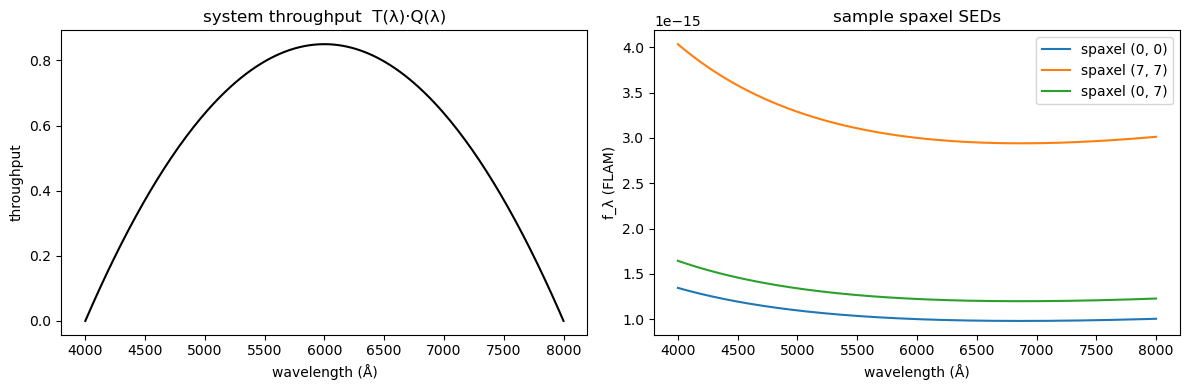

In [3]:
from synphot import SpectralElement
from synphot.models import Empirical1D

T = np.clip(1 - ((wave.value - 6000) / 2000)**2, 0, None)   # smooth passband centered at 6000 A
Q = 0.85 * np.ones(nw)                                       # flat 85% QE (stand-in)
band = SpectralElement(Empirical1D, points=wave, lookup_table=T * Q)
area = 1e4 * u.cm**2                                         # collecting area (1 m^2)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(wave.value, (T*Q), 'k'); ax[0].set_title("system throughput  T(λ)·Q(λ)")
ax[0].set_xlabel("wavelength (Å)"); ax[0].set_ylabel("throughput")
for (i, j) in [(0,0), (7,7), (0,7)]:
    ax[1].plot(wave.value, flux[i, j].value, label=f"spaxel {(i,j)}")
ax[1].set_title("sample spaxel SEDs"); ax[1].set_xlabel("wavelength (Å)")
ax[1].set_ylabel("f_λ (FLAM)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 2. Does `synphot.Observation` batch-integrate the cube? (the ADR's open question)

`synphot.Observation` duck-types specutils input: given a `Spectrum1D` it calls
`SourceSpectrum.from_spectrum1d(spec)`, which hands `spec.flux` to an `Empirical1D` model as its
`lookup_table` (`synphot/spectrum.py:927`). That model is 1-D only. So the prediction from source is:
a **1-D** `Spectrum1D` is accepted, a **multidimensional** one is rejected. Let's confirm both.

In [4]:
from synphot import SourceSpectrum, Observation

# (a) a single 1-D spaxel as a Spectrum1D -> accepted?
one = Spectrum1D(spectral_axis=wave, flux=flux[0, 0])
try:
    obs1 = Observation(one, band, force='taper')
    print("[1-D Spectrum1D]  accepted -> countrate =", round(obs1.countrate(area=area).value, 2), "ct/s")
except Exception as e:
    print("[1-D Spectrum1D]  FAILED:", type(e).__name__, "->", str(e)[:120])

# (b) the full (nx,ny,nw) cube as a Spectrum1D -> one-call batch integration?
try:
    obsN = Observation(cube, band, force='taper')
    cr = obsN.countrate(area=area)
    print("[cube Spectrum1D] accepted -> countrate shape:", np.shape(cr))
except Exception as e:
    print("[cube Spectrum1D] FAILED:", type(e).__name__, "->", str(e)[:120])

[1-D Spectrum1D]  accepted -> countrate = 7003.8 ct/s
[cube Spectrum1D] FAILED: ValueError -> lookup_table should be an array with 1 dimensions.


### Answer

**synphot does *not* batch-integrate a multidimensional `Spectrum1D`.** A 1-D spaxel is accepted (it is
an alternate single-spectrum format), but the full cube raises
`ValueError: lookup_table should be an array with 1 dimensions` — `Empirical1D`/astropy `Tabular1D`
underneath is strictly 1-D. **Per-spaxel iteration is required.**

This resolves the ADR's open item: for the R&D validation path, synphot is a **single-spectrum engine**;
the cube is handled by looping. (It also underscores *why* the eventual component is a from-scratch
vectorized reimplementation rather than a synphot wrapper — batching over spaxels is precisely what
synphot cannot do and what a GPU/autodiff implementation gives for free.)

## 3. Per-spaxel band integration → count-rate and magnitude maps

We loop over the `8 × 8` spaxels, integrating each through the band, and assemble a count-rate map and
an AB-magnitude map.

> **Steering note (ADR soft constraint).** This explicit Python loop is the R&D reference, *not* the
> shape of the eventual component. The ADR calls for the differentiable reimplementation to be
> vectorized/GPU-native (a single tensor contraction over the wavelength axis does all spaxels at once).
> We keep count rate / flux **linear** here; magnitude is computed only as the human-facing QC output,
> never an intermediate — consistent with the ADR's "magnitude is logarithmic, never an internal node"
> rule.

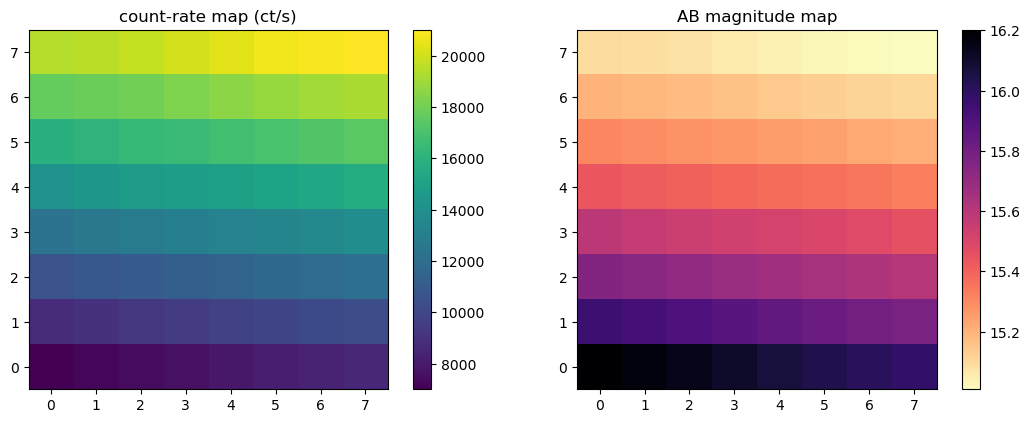

count-rate range: 7004 – 21011 ct/s
AB mag range:     15.009 – 16.202


In [5]:
cr_map = np.zeros((nx, ny))
ab_map = np.zeros((nx, ny))
for i in range(nx):
    for j in range(ny):
        sp = SourceSpectrum(Empirical1D, points=wave, lookup_table=flux[i, j])
        o = Observation(sp, band, force='taper')
        cr_map[i, j] = o.countrate(area=area).value
        ab_map[i, j] = o.effstim(flux_unit=u.ABmag).value

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
im0 = ax[0].imshow(cr_map, origin="lower", cmap="viridis")
ax[0].set_title("count-rate map (ct/s)"); fig.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(ab_map, origin="lower", cmap="magma_r")
ax[1].set_title("AB magnitude map"); fig.colorbar(im1, ax=ax[1])
plt.tight_layout(); plt.show()
print("count-rate range: %.0f – %.0f ct/s" % (cr_map.min(), cr_map.max()))
print("AB mag range:     %.3f – %.3f" % (ab_map.min(), ab_map.max()))

## 4. Physics validation against a hand-computed reference

For one spaxel we reproduce synphot's numbers from first principles, so the physics — not just the API —
is what we trust.

**Count rate.** Photons, not energy, are what the detector counts. Convert the SED `f_λ` (FLAM) to a
photon flux density and integrate through the band over the collecting area `A`:

$$\text{photlam}(\lambda) = f_\lambda(\lambda)\,\frac{\lambda}{h c}, \qquad
  \text{CR} = A \int f_\lambda(\lambda)\,P(\lambda)\,\frac{\lambda}{h c}\,d\lambda \;\;[\text{ct/s}]$$

with `P = T·Q`.

**AB magnitude.** Photon-weighted mean flux density, referred to the band's pivot wavelength:

$$\langle f_\lambda\rangle=\frac{\int f_\lambda P\,\lambda\,d\lambda}{\int P\,\lambda\,d\lambda},\quad
  \lambda_p=\sqrt{\frac{\int P\,\lambda\,d\lambda}{\int P/\lambda\,d\lambda}},\quad
  f_\nu=\langle f_\lambda\rangle\frac{\lambda_p^2}{c},\quad
  m_{AB}=-2.5\log_{10}\!\frac{f_\nu}{3631\,\text{Jy}}.$$

In [6]:
i, j = 7, 7   # a bright corner spaxel
flam = flux[i, j]
w = wave.value

# --- count rate, by hand (trapezoid) ---
photlam = flam.value * wave.to_value(u.cm) / (h.to_value(u.erg * u.s) * c.to_value(u.cm / u.s))
cr_hand = area.value * np.trapz(photlam * (T * Q), w)
sp = SourceSpectrum(Empirical1D, points=wave, lookup_table=flam)
o = Observation(sp, band, force='taper')
cr_syn = o.countrate(area=area).value

# --- AB magnitude, by hand ---
P = T * Q
mean_flam = np.trapz(flam.value * P * w, w) / np.trapz(P * w, w)
pivot = np.sqrt(np.trapz(P * w, w) / np.trapz(P / w, w)) * u.AA
f_nu = ((mean_flam * (u.erg/u.s/u.cm**2/u.AA)) * pivot**2 / c).to(u.erg/u.s/u.cm**2/u.Hz)
ab_hand = -2.5 * np.log10((f_nu / (3631 * u.Jy)).to_value(u.dimensionless_unscaled))
ab_syn = o.effstim(flux_unit=u.ABmag).value

print(f"spaxel {(i,j)}")
print(f"  count rate : hand = {cr_hand:12.4f}   synphot = {cr_syn:12.4f}   rel.diff = {abs(cr_hand-cr_syn)/cr_syn:.2e}")
print(f"  AB mag     : hand = {ab_hand:12.5f}   synphot = {ab_syn:12.5f}   diff     = {abs(ab_hand-ab_syn):.2e} mag")
print(f"  pivot wavelength = {pivot:.1f}")
assert abs(cr_hand - cr_syn)/cr_syn < 1e-4
assert abs(ab_hand - ab_syn) < 1e-3
print("\nPASS: hand-computed physics reproduces synphot to <1e-4 (count rate) and <1e-3 mag (AB).")

spaxel (7, 7)
  count rate : hand =   21011.3416   synphot =   21011.4031   rel.diff = 2.93e-06
  AB mag     : hand =     15.00891   synphot =     15.00885   diff     = 6.56e-05 mag
  pivot wavelength = 5931.2 Angstrom

PASS: hand-computed physics reproduces synphot to <1e-4 (count rate) and <1e-3 mag (AB).


## 5. Findings vs. the ADR's assumptions

| ADR-0001 statement | Verified? | Finding |
|---|---|---|
| specutils `Spectrum1D` "natively supports N-dimensional flux arrays sharing one spectral axis (the exact shape of a DIRSIG (x, y, λ) cube)". | ✅ | Confirmed. An `(8,8,200)` FLAM cube lives in one `Spectrum1D` with a single `spectral_axis`. |
| "`synphot.Observation` accepts a specutils `Spectrum1D` as its source-spectrum argument." | ✅ (1-D only) | True **only for a 1-D flux**. `Observation` duck-types it via `SourceSpectrum.from_spectrum1d`. |
| **Open question:** does `Observation` batch-integrate a multidimensional `Spectrum1D`, or require per-spaxel iteration? | ✅ **resolved** | **No batch integration.** A cube-shaped `Spectrum1D` raises `ValueError: lookup_table should be an array with 1 dimensions`. **Per-spaxel iteration is required** in the synphot R&D path. |
| SED × bandpass × QE → magnitude is the physics to validate and later reimplement. | ✅ | Count rate and AB magnitude reproduced from first principles to `<1e-4` and `<1e-3 mag`. This is the reference the differentiable component (Action Item 4) must match. |

### Consequences for Action Item 4 (the differentiable reimplementation — *not started here*)
- The per-spaxel limitation is a synphot property, **not** a physics constraint. The target component
  should integrate the whole `(x, y, λ)` cube as one **vectorized** wavelength-axis contraction
  (`∫ f_λ·P·λ/hc dλ` → einsum/tensordot), which is trivially GPU/autodiff-friendly.
- Keep **linear count rate / flux** as the internal quantity; emit **magnitude only at the boundary**
  (the SatSim handoff, and QC), per the ADR's linear-vs-log rule.
- Framework choice (JAX / PyTorch / TensorFlow) remains a **hard-stop decision** — deliberately not made
  here.

### Handoff shape (informational)
The natural product of this stage is a per-spaxel **magnitude map** (`ab_map` above). That is exactly
the scalar-per-object quantity SatSim consumes — i.e. this band-integration layer is what supplies
SatSim's missing color term, one magnitude map per bandpass, computed offline from the DIRSIG cube.
